#### Research question: "Which weather factors most strongly drive daily electricity demand and to what extent can electricity demand be predicted from weather factors?
Since my research question is about daily electricity demand, I merged the data by date instead of the full timestamp. The time of day isn't really relevant to my question as I only care about how a whole day's weather relates to that day's demand and not how demand changes hour to hour. 

In [262]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("old_model_data.csv")

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34506 entries, 0 to 34505
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          34506 non-null  object 
 1   date           34506 non-null  object 
 2   max_temp       34506 non-null  float64
 3   mean_temp      34506 non-null  float64
 4   min_temp       34506 non-null  float64
 5   max_dew        34506 non-null  float64
 6   mean_dew       34506 non-null  float64
 7   min_dew        34506 non-null  float64
 8   max_wet_bulb   34501 non-null  float64
 9   mean_wet_bulb  34501 non-null  float64
 10  min_wet_bulb   34501 non-null  float64
 11  max_humidity   34506 non-null  float64
 12  mean_humidity  34506 non-null  float64
 13  min_humidity   34506 non-null  float64
 14  max_wind       25869 non-null  float64
 15  mean_wind      25869 non-null  float64
 16  min_wind       25869 non-null  float64
 17  max_gust       25848 non-null  float64
 18  mean_g

In [264]:
df.isnull().sum()

state               0
date                0
max_temp            0
mean_temp           0
min_temp            0
max_dew             0
mean_dew            0
min_dew             0
max_wet_bulb        5
mean_wet_bulb       5
min_wet_bulb        5
max_humidity        0
mean_humidity       0
min_humidity        0
max_wind         8637
mean_wind        8637
min_wind         8637
max_gust         8658
mean_gust        8658
min_gust         8658
max_pressure        5
mean_pressure       5
min_pressure        5
total_rain          8
peak_demand         0
mean_demand         0
mean_price          0
dtype: int64

In [265]:
df.groupby('state')['mean_wind'].sum()

state
NSW1        0.000000
QLD1    52468.187795
SA1     78200.089435
TAS1    89415.152899
VIC1    45901.010950
Name: mean_wind, dtype: float64

Here i can obviously see that in every single NSW row, there is no values for mean wind.
- After further investigation, the raw untouched .txt file containing all NSW weather data had every column for gust and wind empty, meaning that this issue is a data collection error, rather than a data merging/wrangling error
- In order to resolve this issue, I will have to remove wind and gust from my EDA and Modelling as imputation is not possible as NSW is in a different region from other states, and is likely to have different wind and gust characteristics.
- Removing NSW entirely from this project is also not an option, as it contains a significant amount of the electricity demand data, and discarding it would reduce the dataset's coverage and could bias the analysis toward the remaining four states

In [268]:
drop_cols = [
    'max_wind', 'mean_wind',
    'min_wind', 'max_gust',
    'mean_gust', 'min_gust'
]
df = df.drop(columns=drop_cols)

In [270]:
df = df.dropna()

In [273]:
df = df.drop_duplicates()

In [276]:
df.describe() # ensure there are no unrealistic values

,max_temp,mean_temp,min_temp,max_dew,mean_dew,min_dew,max_wet_bulb,mean_wet_bulb,min_wet_bulb,max_humidity,mean_humidity,min_humidity,max_pressure,mean_pressure,min_pressure,total_rain,peak_demand,mean_demand,mean_price
count,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000
mean,22.170690,17.311921,13.077871,12.787232,9.871345,6.790787,15.837237,13.457201,11.031992,84.639550,65.053176,43.947671,1019.585133,1016.591073,1013.733421,2.875036,5435.071059,4620.220691,51.469675
std,6.039452,5.207560,5.011953,4.895110,5.204897,5.958510,4.342641,4.385186,4.643765,10.921549,13.209621,14.948280,6.631343,7.223711,7.929448,8.381220,3260.968780,2767.667228,77.025013
min,6.200000,3.493750,-0.300000,-5.800000,-9.316000,-39.200000,3.300000,1.937037,-0.900000,17.000000,7.375000,1.000000,987.000000,983.178947,975.300000,0.000000,928.290000,772.840625,-182.918542
25%,17.500000,13.281250,9.300000,9.100000,5.930769,2.600000,12.400000,10.025000,7.500000,79.000000,57.458333,34.000000,1015.300000,1012.043750,1008.800000,0.000000,1705.330000,1416.203333,25.632083
50%,21.900000,16.989583,12.700000,12.400000,9.242000,6.100000,15.600000,13.030612,10.500000,87.000000,66.437500,45.000000,1019.700000,1016.845833,1014.200000,0.000000,6225.486670,5369.615972,35.779375
75%,26.300000,21.170833,16.800000,16.400000,13.647917,11.000000,19.200000,16.750000,14.400000,93.000000,74.020833,54.000000,1024.000000,1021.389583,1019.100000,2.000000,7539.590000,6397.450625,57.637083
max,47.400000,38.875000,34.100000,41.000000,24.660417,23.000000,41.000000,26.466667,25.000000,123.000000,100.000000,100.000000,1041.800000,1040.029167,1038.100000,182.600000,14579.860000,11539.817500,3377.320417


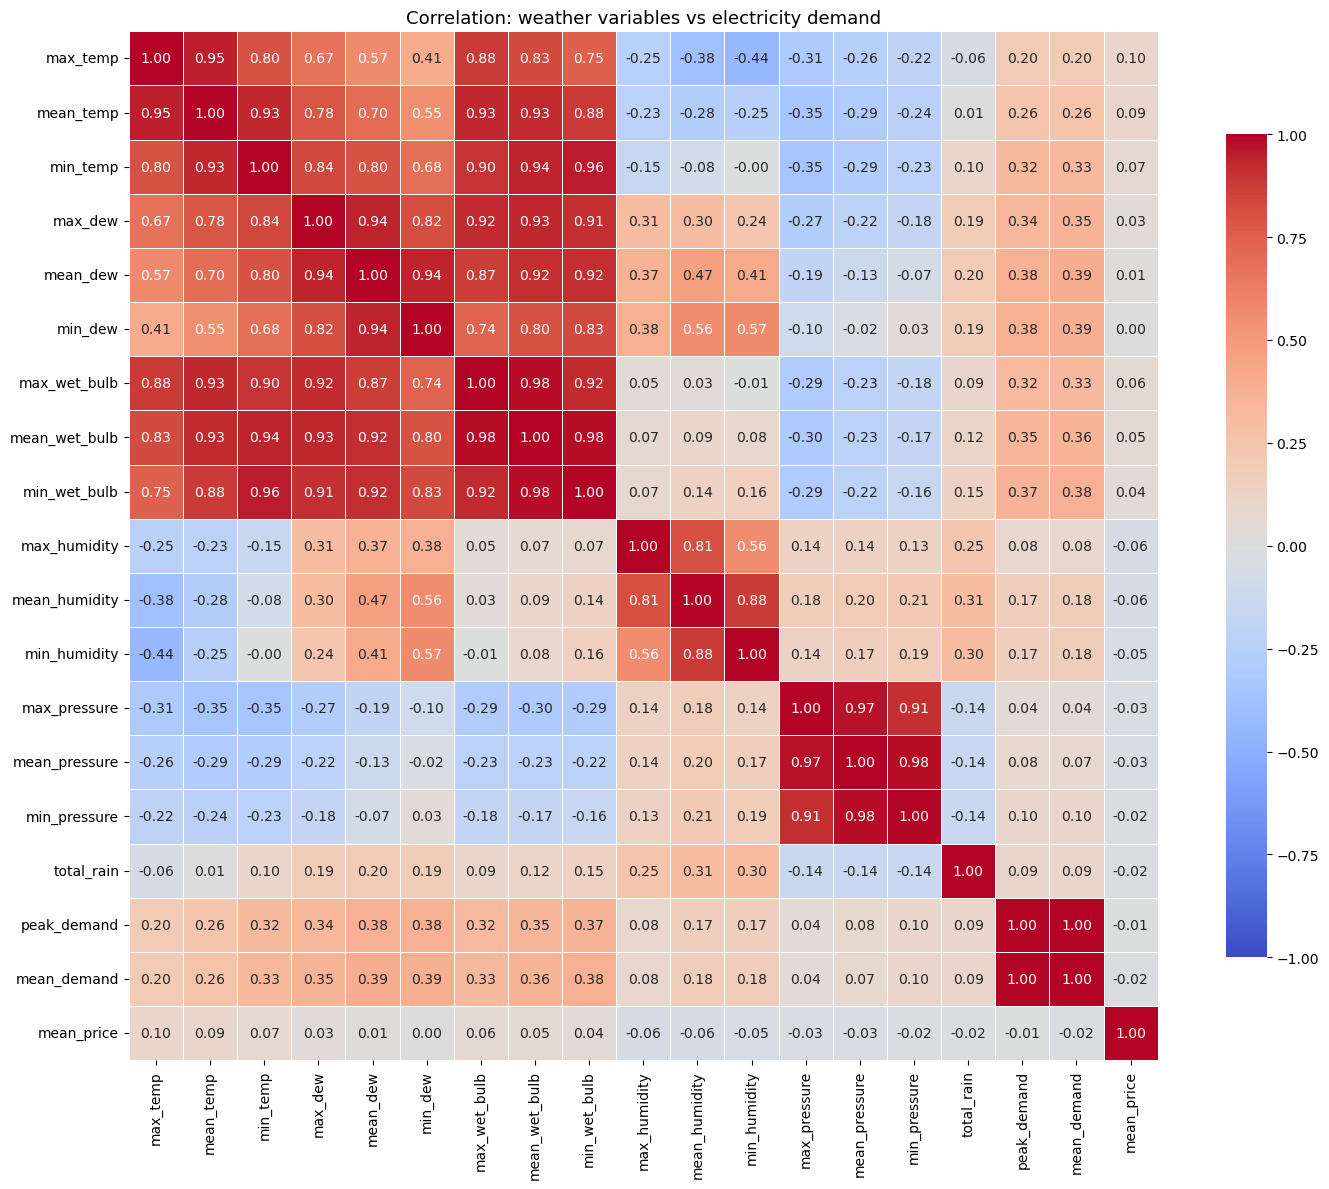

In [277]:
# Correlation on the numeric columns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15, 12))
sns.heatmap(
    corr,
    annot=True,          # write the number in each cell
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # red = positive, blue = negative
    center=0,            # 0 correlation = white
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation: weather variables vs electricity demand", fontsize=13)
plt.tight_layout()
plt.savefig('my_figure.png', dpi=150, bbox_inches='tight')

plt.show()

I will use peak as my target, because my research question focuses on how weather drives/pushes demand

For my variables/features, i will use max_temp, mean_humidity, mean_wind, total_rain, mean_pressure

I will choose mean_temp over max/min as average temperatures matter more. 
- A short burst of 35C weather might not cause a lot of energy demand as it might not have lasted long enough for people to increase electricity usage (air-conditioning). 
- A short burst of high temperature weather might also not affect energy usage if the burst occured during the afternoon and people were at work where air-conditioning is kept on regardless of medium/high temperatures.
- This means that when they get home, the short burst of high temperature weather might have ended, resulting in them not needing air conditioning
- A day with a high mean_temp is able to identify/outline days where people would use energy both at work, and when they get home.
- The same is true for cold days and heating

Comment made after modelling.
- After comparing using both mean_temp and max_temp, mean_temp gave a higher R2 score which confirms my above statement about it being a more accurate predictor in electricity demand

In [279]:
df.describe()

,max_temp,mean_temp,min_temp,max_dew,mean_dew,min_dew,max_wet_bulb,mean_wet_bulb,min_wet_bulb,max_humidity,mean_humidity,min_humidity,max_pressure,mean_pressure,min_pressure,total_rain,peak_demand,mean_demand,mean_price
count,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000,34493.000000
mean,22.170690,17.311921,13.077871,12.787232,9.871345,6.790787,15.837237,13.457201,11.031992,84.639550,65.053176,43.947671,1019.585133,1016.591073,1013.733421,2.875036,5435.071059,4620.220691,51.469675
std,6.039452,5.207560,5.011953,4.895110,5.204897,5.958510,4.342641,4.385186,4.643765,10.921549,13.209621,14.948280,6.631343,7.223711,7.929448,8.381220,3260.968780,2767.667228,77.025013
min,6.200000,3.493750,-0.300000,-5.800000,-9.316000,-39.200000,3.300000,1.937037,-0.900000,17.000000,7.375000,1.000000,987.000000,983.178947,975.300000,0.000000,928.290000,772.840625,-182.918542
25%,17.500000,13.281250,9.300000,9.100000,5.930769,2.600000,12.400000,10.025000,7.500000,79.000000,57.458333,34.000000,1015.300000,1012.043750,1008.800000,0.000000,1705.330000,1416.203333,25.632083
50%,21.900000,16.989583,12.700000,12.400000,9.242000,6.100000,15.600000,13.030612,10.500000,87.000000,66.437500,45.000000,1019.700000,1016.845833,1014.200000,0.000000,6225.486670,5369.615972,35.779375
75%,26.300000,21.170833,16.800000,16.400000,13.647917,11.000000,19.200000,16.750000,14.400000,93.000000,74.020833,54.000000,1024.000000,1021.389583,1019.100000,2.000000,7539.590000,6397.450625,57.637083
max,47.400000,38.875000,34.100000,41.000000,24.660417,23.000000,41.000000,26.466667,25.000000,123.000000,100.000000,100.000000,1041.800000,1040.029167,1038.100000,182.600000,14579.860000,11539.817500,3377.320417


Since low temperatures and high temperatures usually warrant more energy usage, a U shaped curve is created when plotting Temperatures against Energy demand. 
- To account for this, i will investigate into what temperatures people are comfortable with (temperatures that have the least energy demand), and create a new feature called 'temp_discomfort' from it
- This allows me to use general comfortability as a feature instead of just pure temperature

In [280]:
df['state'].unique()

array(['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1'], dtype=object)

<Axes: xlabel='mean_temp', ylabel='peak_demand'>

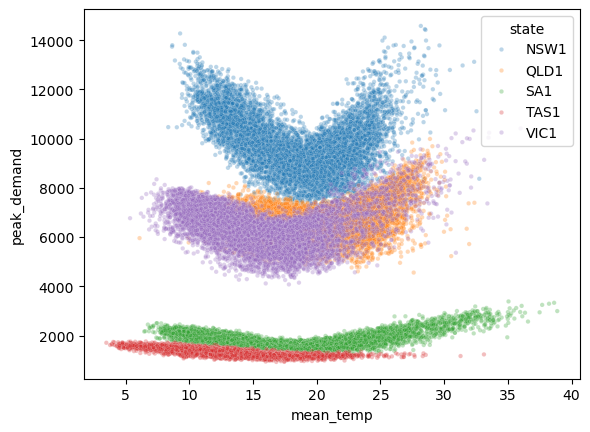

In [281]:
sns.scatterplot(data=df, x='mean_temp', y='peak_demand', hue='state', alpha=0.3, s=10)

### demand_relative feature for normalisation
Above I can see that energy demand varies widely among different states due to the differences in population, economies and size.
- In order to overcome this, i will have to normalise the demand by dividing demand with the state's daily average 'peak_demand' to give a gauge on how much more energy is used on a specific day due to the weather
- This is better than dividing by population, as the population of these states have changed over the years, and would require a separate data source.
- Dividing by population also assumes that population is the only factor in  this gap. (some states have more malls/public areas per capita)
- In this 'demand_relative' feature, a value of 1 would mean that that day's energy demand is the average of the state, and 1.3 would be 30% higher than the state average demand
- This 'demand_relative' feature will be the new target(y)

In [282]:
df['demand_relative'] = df['peak_demand'] / df.groupby('state')['peak_demand'].transform('mean')
df['demand_relative'].describe()

count    34493.000000
mean         1.000000
std          0.130733
min          0.638066
25%          0.908392
50%          0.991428
75%          1.079519
max          1.891536
Name: demand_relative, dtype: float64

<Axes: xlabel='mean_temp', ylabel='demand_relative'>

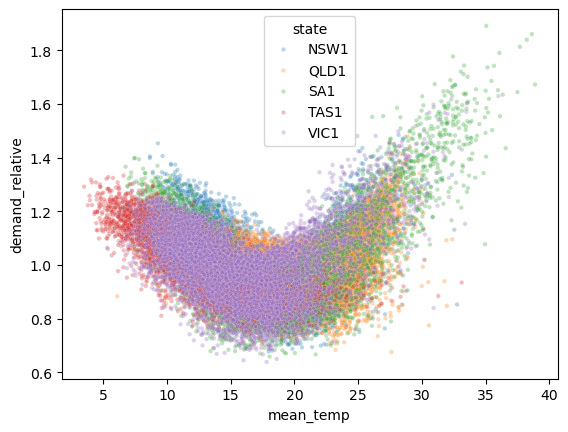

In [283]:
sns.scatterplot(data=df, x='mean_temp', y='demand_relative', hue='state', alpha=0.3, s=10)

As you can see clearly on the scatter plot above, there is a high spread of demand_relative values at any specific temperature points.

By analysing the coefficients of the model I will create, I will be able to get a better idea of what is causing this spread.

### comfort_point feature
Here ill start to create the 'comfort_point' variable (temperature where energy demand is the lowest) 

Ill also create a 'temp_discomfort' feature which will be how many degreees difference a specific row is from the comfort point

In [284]:
demand_by_temp = df.groupby(df['mean_temp'].round())['demand_relative'].mean()
demand_by_temp.idxmin()   # the temperature with the lowest average demand

np.float64(18.0)

In [285]:
comfort_point = demand_by_temp.idxmin() # A discomfort point of 0 is the point/temp of least energy usage

df['temp_discomfort'] = (df['mean_temp'] - comfort_point).abs() # Calculates how far each row's max temp is from the comfort zone
print(comfort_point)

18.0


My original plan was to use 'temp_discomfort' as a gauge of how far that day's peak temperature was from the comfort point.

However, hot days are usually more uncomfortable than cold days, even if they are the same difference from the comfort point (14C vs 34C degree weather)
- To overcome this, i will split the 'temp_discomfort' feature into 2 ('heat_discomfort' and 'cold_discomfort')
- This will allow the model to take into consideration of how warmer days('heat_discomfort') and colder days ('cold_discomfort') affect 'peak_demand' differently and ill be able to get 2 different co-efficients from them


In [286]:
df['heat_discomfort'] = (df['mean_temp'] - comfort_point).clip(lower=0)   # 0 if below comfort
df['cold_discomfort'] = (comfort_point - df['mean_temp']).clip(lower=0)   # 0 if above comfort

### Linear model fitting
- In this section i will use a regression model to answer "Which weather factors (temperature, humidity, wind, rainfall) most strongly drive daily electricity demand?", the first part of my research question
- I will use a linear model as the coefficients are easy to interpret

In [325]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler

X = df[['heat_discomfort', 'cold_discomfort','total_rain', 'mean_pressure','mean_humidity' ]]

y = df['demand_relative']

X_train_lin, X_test_lin, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_lin = StandardScaler()
X_train_lin = scaler_lin.fit_transform(X_train_lin)
X_test_lin  = scaler_lin.transform(X_test_lin)

model = LinearRegression()
model.fit(X_train_lin, y_train)
y_pred_lin = model.predict(X_test_lin)

print('MAE :', mean_absolute_error(y_test, y_pred_lin))
print('RMSE:', root_mean_squared_error(y_test, y_pred_lin))
print()
print("Train R²:", model.score(X_train_lin, y_train))
print("Test R²:", model.score(X_test_lin, y_test))

MAE : 0.07916643550553057
RMSE: 0.0994459088074654

Train R²: 0.43055667713387524
Test R²: 0.4038240100607551


In [326]:
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients.sort_values(key=abs, ascending=False))

heat_discomfort    0.089869
cold_discomfort    0.086793
mean_pressure      0.011273
total_rain         0.003090
mean_humidity      0.000124
dtype: float64


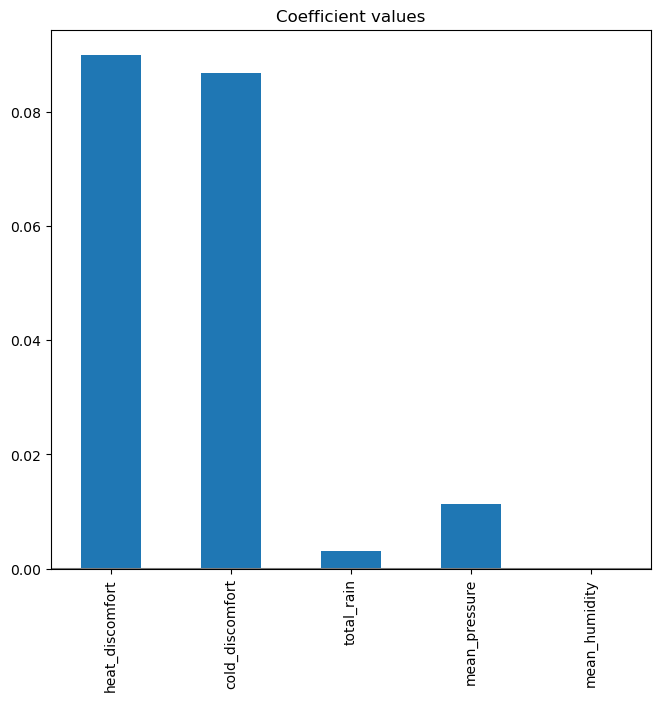

In [327]:
coefficients.plot(kind='bar', figsize = (10,7))
plt.title('Coefficient values')
plt.axhline(y=0, color='.5')
plt.subplots_adjust(left=.3)

In [328]:
df[['mean_humidity','demand_relative']].corr()

,mean_humidity,demand_relative
mean_humidity,1.000000,0.006935
demand_relative,0.006935,1.000000


### Regularisation

Checking the coefficients' stability to see if regularisation can help with possible multicollinearity with the features used

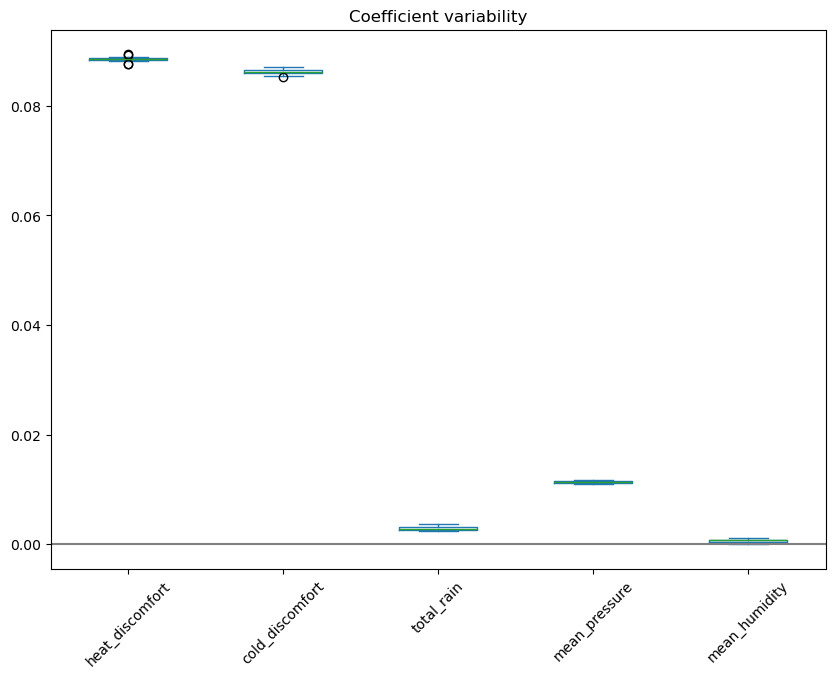

In [329]:
from sklearn.linear_model import Ridge, Lasso 
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold 
from sklearn.metrics import r2_score 
import numpy as np 
import pandas as pd 

from sklearn.model_selection import cross_validate, RepeatedKFold 
import pandas as pd 
import matplotlib.pyplot as plt 

nX = (X - X.mean()) / X.std()

scores = cross_validate(
    LinearRegression(),
    nX, y,                       # ← use normalised nX, not raw X
    cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=42),
    return_estimator=True
)

coefs = pd.DataFrame([est.coef_ for est in scores['estimator']], columns=X.columns)

coefs.plot(kind='box', figsize=(10, 7))
plt.axhline(y=0, color='.5')
plt.title('Coefficient variability')
plt.xticks(rotation=45)
plt.show()

The box plots are quite thin, meaning that the coefficients are stable across multiple splits.

In [330]:
print("Intercept:", model.intercept_)
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef}")

Intercept: 1.0006776948405836
Coefficients:
  heat_discomfort: 0.08986896298270661
  cold_discomfort: 0.08679289131478506
  total_rain: 0.0030897142142731837
  mean_pressure: 0.011272532318626056
  mean_humidity: 0.0001237432462508364


In [332]:
# Finish notes/comments
# Create an additional polynomial model where raw temperatures are used and the U shaped curve is kept
# Create conclusion and present findings of value
# Create a model to predict if a day's demand will exceed the demand_relative = 1

<Axes: xlabel='heat_discomfort', ylabel='demand_relative'>

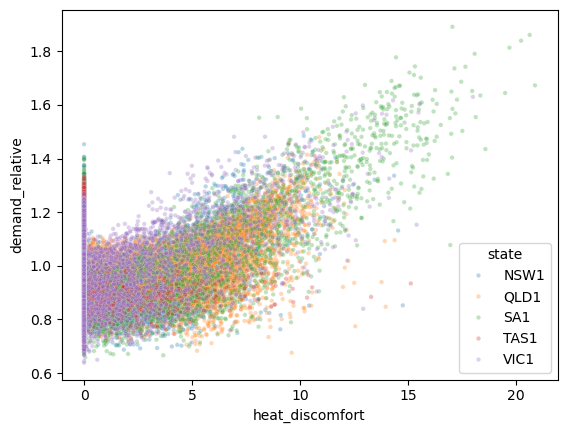

In [333]:
sns.scatterplot(data=df, x='heat_discomfort', y='demand_relative', hue='state', alpha=0.3, s=10)

<Axes: xlabel='cold_discomfort', ylabel='demand_relative'>

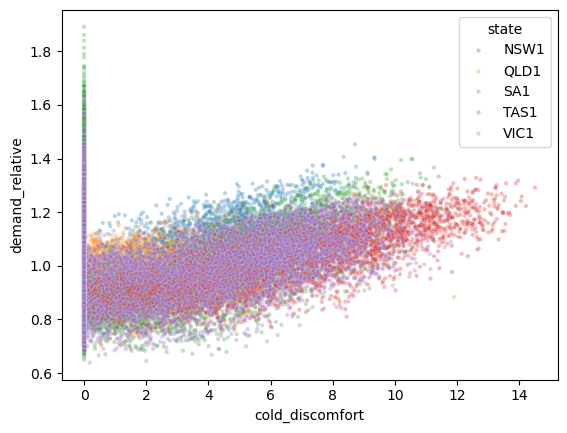

In [335]:
sns.scatterplot(data=df, x='cold_discofort', y='demand_relative', hue='state', alpha=0.3, s=10)

At a fixed discomfort level, demand_relative varies substantially (e.g., ranging from roughly 0.70 to 1.30 at heat_discomfort ≈ 5), meaning temperature discomfort alone doesn't determine demand precisely.

Since the other weather-related coefficients (rain: 0.003, pressure: 0.011, humidity: 0.0001) are all near zero, weather factors are unlikely to explain this spread. This suggests the remaining variation is driven by factors not captured in this model such as patterns, public holidays, special events, or electricity usage habits, rather than by weather itself.

This is consistent with the model's R² of ~0.43:
- Since weather explains under half the variance, the remaining ~57%, which can be seen as the wide spread in the scatterplot, is likely credited to unmodelled factors rather than additional weather variables, given how small their coefficients are.

# More modelling

I would like to create a model that predicts whether the features within a row will cause that day's demand to be above or below the average daily demand. I believe that this model is useful and has applicable uses for energy suppliers when it comes to estimating how much power to generate

Since the feature I created, demand_relative, already expresses each day's demand as a ratio to its state's average daily demand, I just need to create a new feature that checks whether this ratio exceeds 1 (meaning demand was above that state's average) or not.

This feature will have a value of 1 if that day's demand is higher than the daily average, and a 0 if it is below

In [336]:
# demand_relative > 1 means above that state's average demand; < 1 means below
df['above_avg_demand'] = (df['demand_relative'] > 1).astype(int)

# Check the balance of the new target
print(df['above_avg_demand'].value_counts())

above_avg_demand
0    18161
1    16332
Name: count, dtype: int64


I will use logistic regression as my model, as my target's values are binary (0's and 1's).

In [339]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features
X = df[['heat_discomfort', 'cold_discomfort', 'mean_humidity', 'total_rain', 'mean_pressure']]
y = df['above_avg_demand']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fitting logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.740397159008552
[[2834  798]
 [ 993 2274]]
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      3632
           1       0.74      0.70      0.72      3267

    accuracy                           0.74      6899
   macro avg       0.74      0.74      0.74      6899
weighted avg       0.74      0.74      0.74      6899



Overall this model has a very reasonable score of 0.74 accuracy. 

Comparing this to the linear regression model, this shows that while the spread of demand for a specific temperature point is caused more by un-quantified factors rather than weather factors, the information within the data-set is still able to provide useful data and information that allows for the reliable estimation of whether a day's demand will exceed the average.

This means that while weather may not be able to precisely determine the exact level of demand, it still contains enough information to answer this simpler, practical question, reinforcing its usefulness for tasks like energy supply planning

## MY KEY CONCLUSIONS — dont overlap or contradict

- NSW's missing wind/gust is a genuine data collection error (confirmed via the raw .txt file), not a wrangling mistake — and it can't be imputed because NSW's location means its wind/gust patterns would differ from other states.
mean_temp is a better predictor than max_temp — because a brief temperature spike doesn't necessarily change behaviour (e.g. people are still at work with AC running regardless, or the spike ends before they're home), whereas mean_temp captures sustained conditions throughout the day. Confirmed empirically — mean_temp gave a higher R² than max_temp.
- Heat and cold discomfort are NOT symmetric — a day equally far above the comfort point as another is below it will not have the same impact on demand, because extreme heat and extreme cold are felt differently. This is why heat_discomfort and cold_discomfort were split into separate features with separate coefficients, rather than one combined measure.
- The coefficients are stable (not distorted by multicollinearity) — confirmed via cross-validation boxplots (thin/narrow boxes), so the coefficient values and rankings can be trusted.
Weather explains under half of demand's variance (R² ≈ 0.43) — meaning temperature and other weather factors alone do not precisely determine demand.
- The wide spread in demand at any fixed discomfort level is NOT caused by other weather variables (rain, pressure, humidity all have near-zero coefficients) — it is instead attributed to unmodelled, non-weather factors: day-of-week patterns, public holidays, special events, or electricity usage habits. Do not attribute this spread to weather variables not included in the model — the evidence points away from weather as the cause.
- Even though weather can't precisely predict the exact demand level, it CAN reliably classify whether a day will be above or below average demand (0.74 accuracy, balanced across both classes). This is presented as a meaningful, complementary finding — not a contradiction of point 5 — because predicting a simple yes/no is a fundamentally easier task than predicting an exact value.
- demand_relative (normalised by each state's own average) is the correct way to compare demand across states — not raw peak_demand (which varies by population/economy/size) and not population-adjusted demand (population data is unreliable/incomplete and isn't the only driver of the gap).